In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [3]:
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

data = pd.DataFrame(x, columns=diabetes.feature_names)

data["Disease Progression"] = y
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


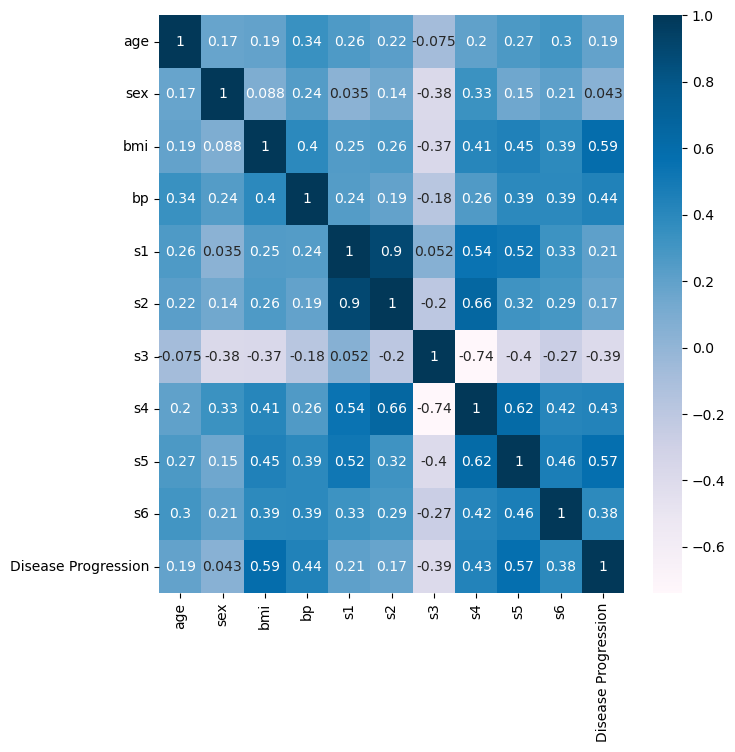

In [4]:
import seaborn as sns
fig = plt.figure(figsize = (7.5,7.5))
cor = data.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.PuBu)
plt.show()

In [5]:
cor_target = abs(cor["Disease Progression"])

relevant_features = []
names = []
for name, value in cor_target.items():
    if name != "Disease Progression" and value > 0.02:
        relevant_features.append(value)
        names.append(name)

print(names)
print(relevant_features)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
[0.1878887507189197, 0.043061998451605396, 0.5864501344746885, 0.44148175856257105, 0.21202248101455062, 0.1740535869687425, 0.39478925067091836, 0.43045288474477283, 0.5658825924427434, 0.3824834842485807]


In [6]:
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
from sklearn.model_selection import train_test_split

x = data[names]
y = data['Disease Progression']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

prod = GradientBoostingRegressor(random_state=42)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'min_samples_leaf': randint(1, 10)
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist, n_iter=100, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)
random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000260FEB524E0>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000260FE61C170>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000260FEC88890>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000260FE55DAF0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000260FEC885F0>},
                   random_state=42, scoring='r2')

In [10]:

final_prod = random_search.best_estimator_
final_prod

GradientBoostingRegressor(learning_rate=0.05442607898601997, max_depth=2,
                          n_estimators=101, random_state=42,
                          subsample=0.8010716092915446)

In [11]:
print(f"Best CV R²: {random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")
print(f"Test R²:  {final_prod.score(x_test, y_test):.4f}")

Best CV R²: 0.4154
Best params: {'learning_rate': 0.05442607898601997, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 101, 'subsample': 0.8010716092915446}
Test R²:  0.4849


Linear Regression: r2 = 0.4130148553474924
Random Forest Regression: r2 = 0.4613341
Gradient Boosting Regressor Using GridSearchCV: r2 = 0.47593
Gradient Boosting Regressor Using RandomzedSearchCV: r2 = 0.484918

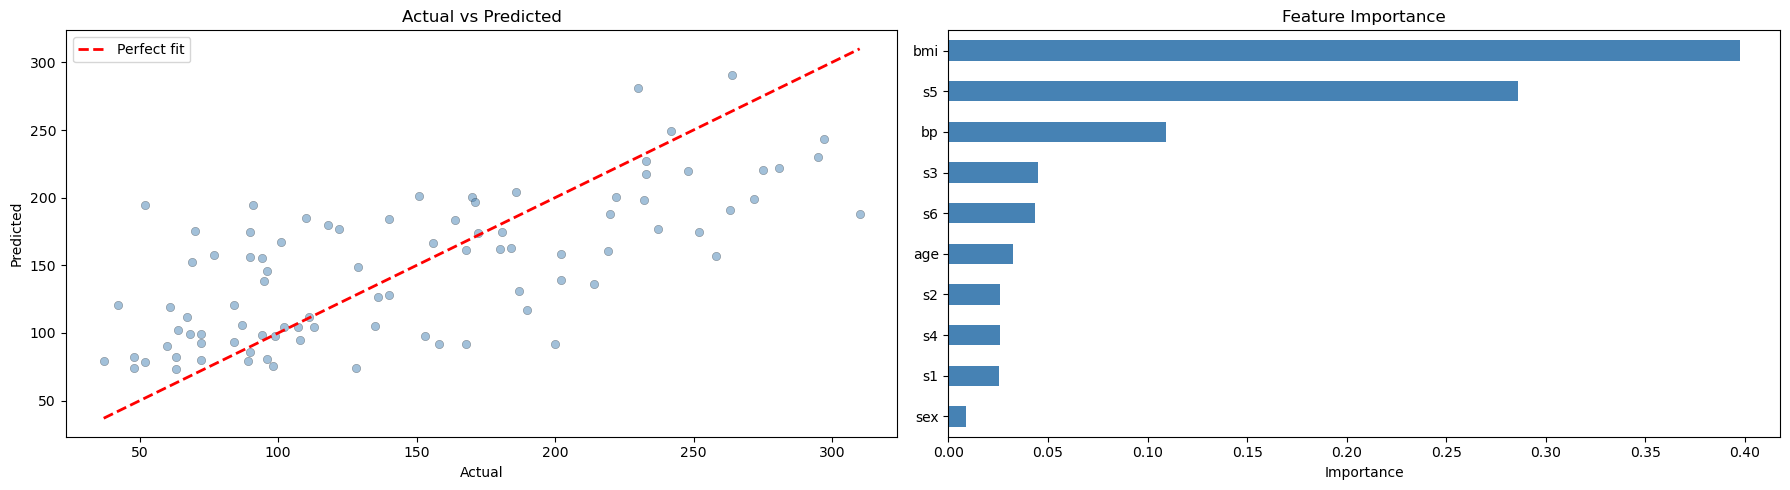

In [16]:
y_pred = final_prod.predict(x_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color="steelblue", edgecolors="k", linewidths=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2, label="Perfect fit")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
feat_imp = pd.Series(final_prod.feature_importances_, index=x_train.columns)
feat_imp.sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [13]:
final_prod.score(x_test, y_test)

0.4849183561007232